In [30]:
import pandas as pd
import scipy.stats
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

### Preliminary Data Overview

In [31]:
df = pd.read_csv('data/card transactions_2025.csv')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98393 entries, 0 to 98392
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Recnum             98393 non-null  int64  
 1   Cardnum            98393 non-null  int64  
 2   Date               98393 non-null  object 
 3   Merchnum           94970 non-null  object 
 4   Merch description  98393 non-null  object 
 5   Merch state        97181 non-null  object 
 6   Merch zip          93664 non-null  float64
 7   Transtype          98393 non-null  object 
 8   Amount             98393 non-null  float64
 9   Fraud              98393 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 7.5+ MB


In [33]:
df['Merch zip'] = df['Merch zip'].astype(str)
df['Recnum'] = df['Recnum'].astype(str)
df['Cardnum'] = df['Cardnum'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')

In [34]:
pd.DataFrame({
    'count': df.count(),
    'isna': df.isna().sum(),
    '% pop': 1 - df.isna().sum() / len(df)
})

,count,isna,% pop
Recnum,98393,0,1.000000
Cardnum,98393,0,1.000000
Date,98393,0,1.000000
Merchnum,94970,3423,0.965211
Merch description,98393,0,1.000000
Merch state,97181,1212,0.987682
Merch zip,98393,0,1.000000
Transtype,98393,0,1.000000
Amount,98393,0,1.000000
Fraud,98393,0,1.000000


In [35]:
df.describe()

,Date,Amount,Fraud
count,98393,9.839300e+04,98393.000000
mean,2010-06-25 23:24:49.020560640,4.242909e+02,0.025327
min,2010-01-01 00:00:00,1.000000e-02,0.000000
25%,2010-04-03 00:00:00,3.337000e+01,0.000000
50%,2010-06-27 00:00:00,1.370300e+02,0.000000
75%,2010-09-12 00:00:00,4.250000e+02,0.000000
max,2010-12-31 00:00:00,3.102046e+06,1.000000
std,NaN,9.922487e+03,0.157117


### Exploration of Numeric Fields

#### Transaction Amount

As we can tell, the only column that is numeric is Amount, whereas the others are categorical variables.

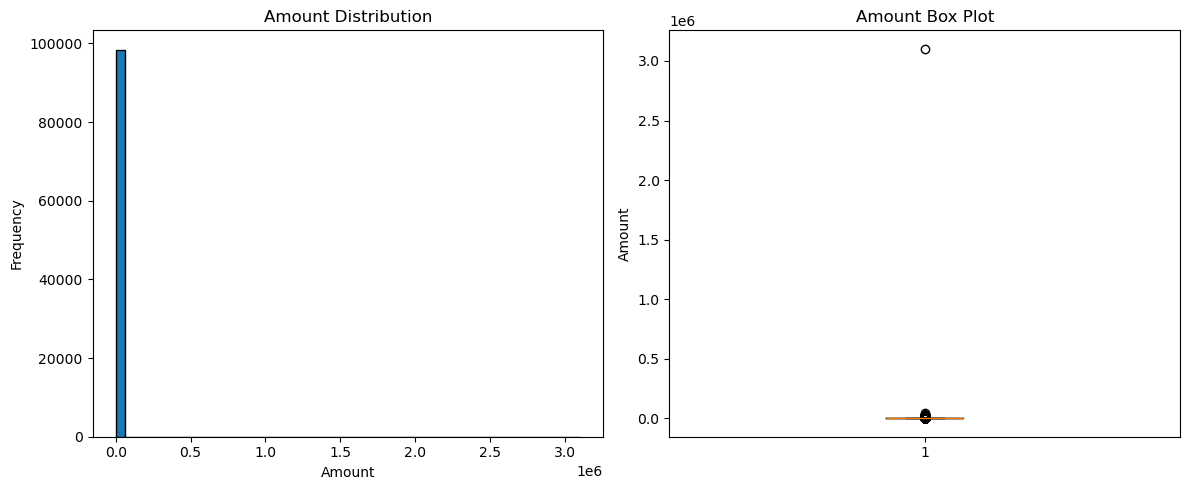

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Amount'], bins=50, edgecolor='black')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Amount Distribution')

plt.subplot(1, 2, 2)
plt.boxplot(df['Amount'])
plt.ylabel('Amount')
plt.title('Amount Box Plot')

plt.tight_layout()
plt.show()

By looking at this entry, this transaction is significantly higher than all other transactions in the dataset. It is also a non-fraud transaction. Let's remove this observation.

In [37]:
df[df['Amount'] > 3000000]

,Recnum,Cardnum,Date,Merchnum,Merch description,Merch state,Merch zip,Transtype,Amount,Fraud
53491,53492,5142189135,2010-07-13,NaN,INTERMEXICO,NaN,nan,P,3102045.53,0


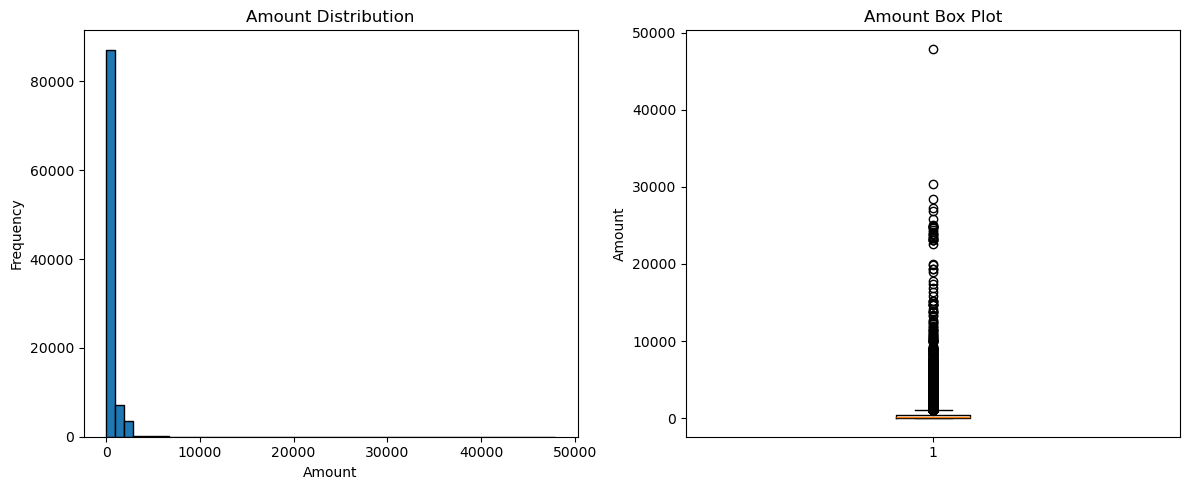

In [ ]:
df = df[df['Amount'] < 3000000]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Amount'], bins=50, edgecolor='black')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Amount Distribution')

plt.subplot(1, 2, 2)
plt.boxplot(df['Amount'])
plt.ylabel('Amount')
plt.title('Amount Box Plot')

plt.tight_layout()
plt.show()

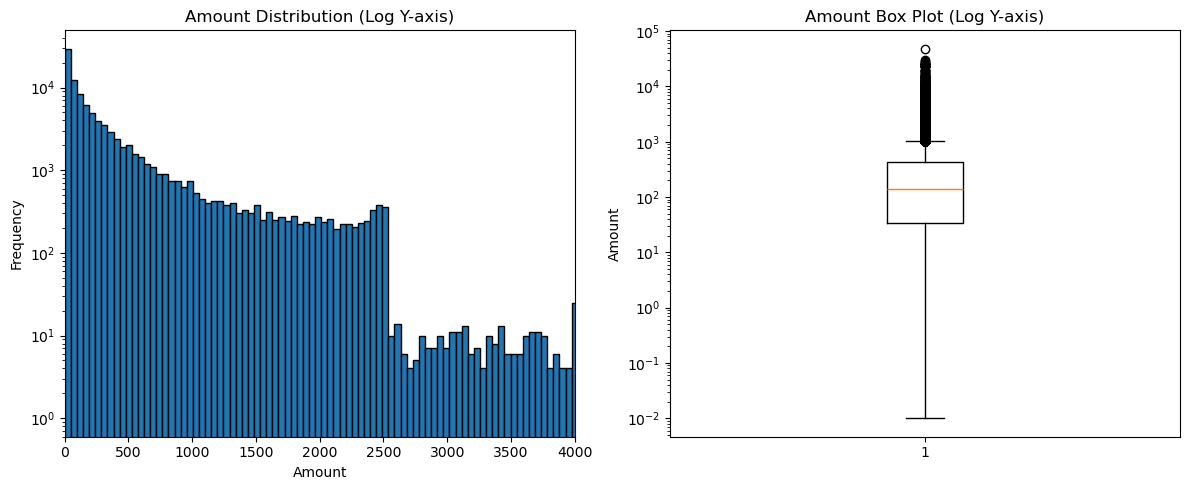

In [39]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Amount'], bins=1000, edgecolor='black')
plt.xlim(0, 4000)
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Amount Distribution (Log Y-axis)')

plt.subplot(1, 2, 2)
plt.boxplot(df['Amount'])
plt.ylabel('Amount')
plt.yscale('log')
plt.title('Amount Box Plot (Log Y-axis)')

plt.tight_layout()
plt.show()

Transaction amounts show a sharp decline at the $2,500 mark. This pattern is consistent with most companies having an internal policy requiring manager approval for expenditures above this threshold.

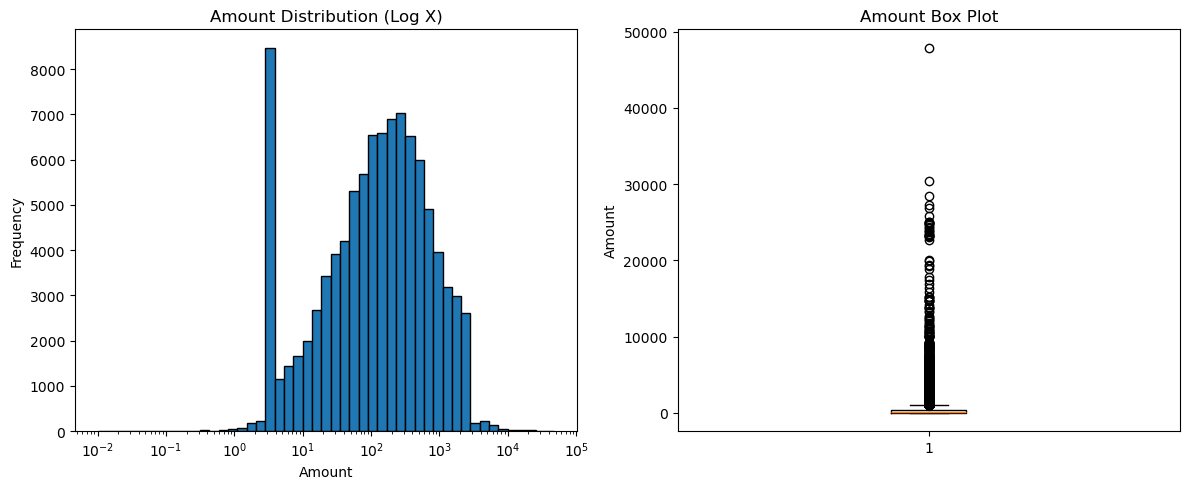

In [40]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Amount'], bins=np.logspace(np.log10(df['Amount'].min()), np.log10(df['Amount'].max()), 50), edgecolor='black')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.xscale('log')
# plt.yscale('log')
plt.title('Amount Distribution (Log X)')

plt.subplot(1, 2, 2)
plt.boxplot(df['Amount'])
plt.ylabel('Amount')
# plt.yscale('log')
plt.title('Amount Box Plot')

plt.tight_layout()
plt.show()

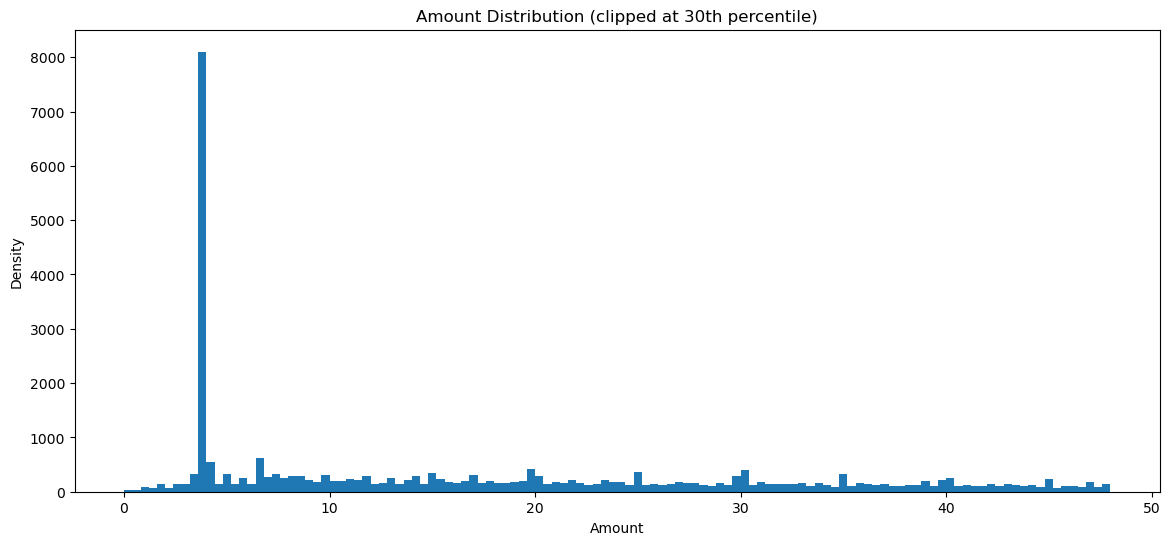

In [41]:
plt.figure(figsize=(14, 6))
upper = df['Amount'].quantile(0.3)
plt.hist(df[df['Amount'] <= upper]['Amount'], bins=120)
plt.xlabel('Amount')
plt.ylabel('Density')
plt.title('Amount Distribution (clipped at 30th percentile)')
plt.show()

In [42]:
df['Amount'].value_counts().head(5)

Amount
3.62    4283
3.67    1620
3.74     913
3.80     827
4.37     378
Name: count, dtype: int64

In [43]:
df[df['Amount'] == 3.62]['Merch description'].value_counts().head(5)

Merch description
FEDEX SHP 05/16/10 AB#    93
FEDEX SHP 05/10/10 AB#    93
FEDEX SHP 06/09/10 AB#    56
FEDEX SHP 06/01/10 AB#    52
FEDEX SHP 01/06/10 AB#    51
Name: count, dtype: int64

In [44]:
df[df['Amount'] == 3.62]['Fraud'].value_counts()

Fraud
0    4283
Name: count, dtype: int64

In [45]:
df[df['Amount'] == 3.67]['Merch description'].value_counts().head(5)

Merch description
FEDEX SHP 06/01/10 AB#    40
FEDEX SHP 08/11/10 AB#    39
FEDEX SHP 09/07/10 AB#    30
FEDEX SHP 08/08/10 AB#    27
FEDEX SHP 05/16/10 AB#    26
Name: count, dtype: int64

In [46]:
df[df['Amount'] == 3.67]['Fraud'].value_counts()

Fraud
0    1620
Name: count, dtype: int64

A notable anomaly was detected in the transaction data: a high-frequency spike at the $3.62 and $3.67 price point. Investigation confirms these transactions primarily consist of uniform charges from FedEx. They are low-risk, non-fraud transactions.

### Exploration of Categorical Fields

#### Date

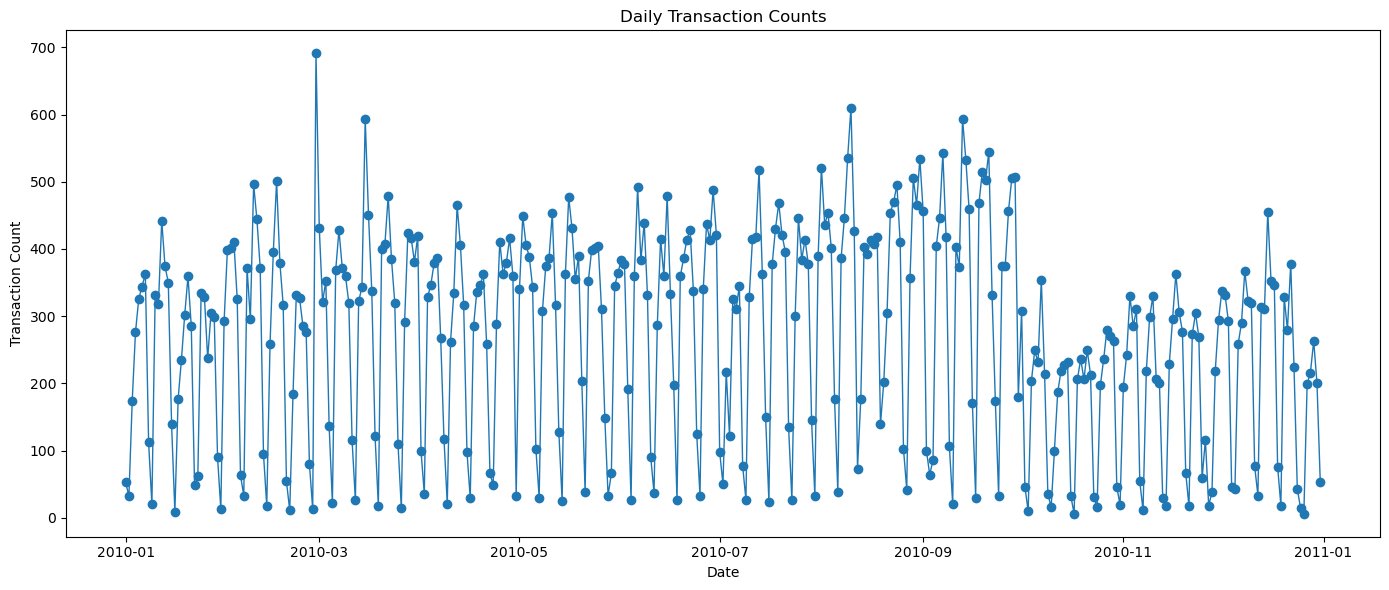

In [47]:
daily_counts = df.groupby(df['Date'].dt.date).size()

plt.figure(figsize=(14, 6))
plt.plot(daily_counts.index, daily_counts.values, marker='o', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Transaction Count')
plt.title('Daily Transaction Counts')
plt.tight_layout()
plt.show()

Transaction volume exhibits a strong weekly pattern. 

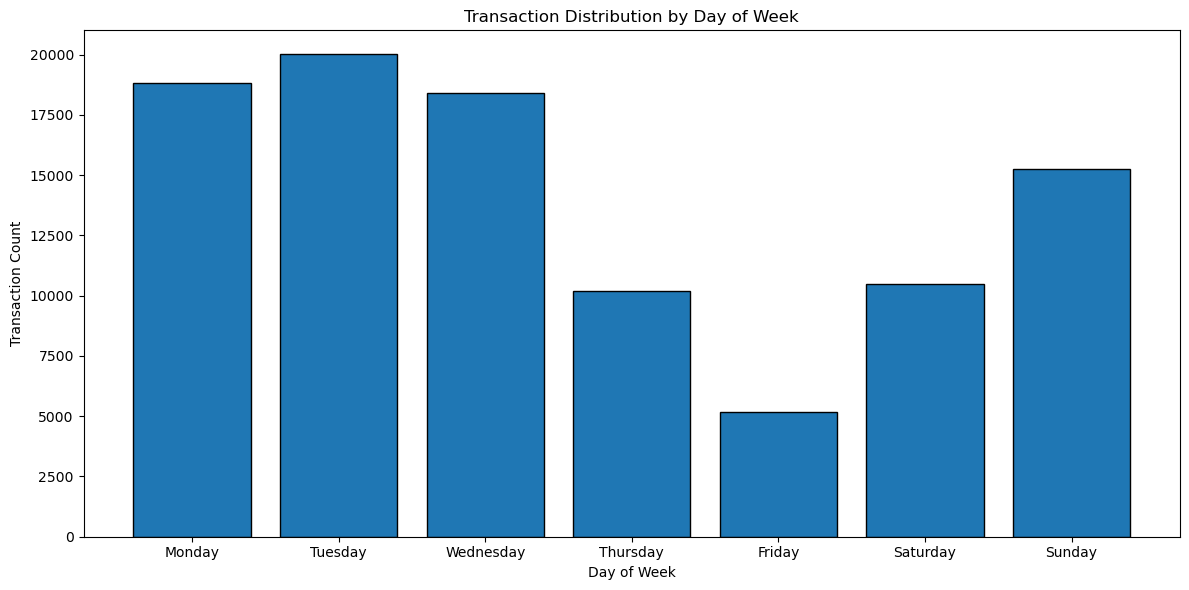

In [48]:
df['day_of_week'] = df['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(12, 6))
plt.bar(day_counts.index, day_counts.values, edgecolor='black')
plt.xlabel('Day of Week')
plt.ylabel('Transaction Count')
plt.title('Transaction Distribution by Day of Week')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

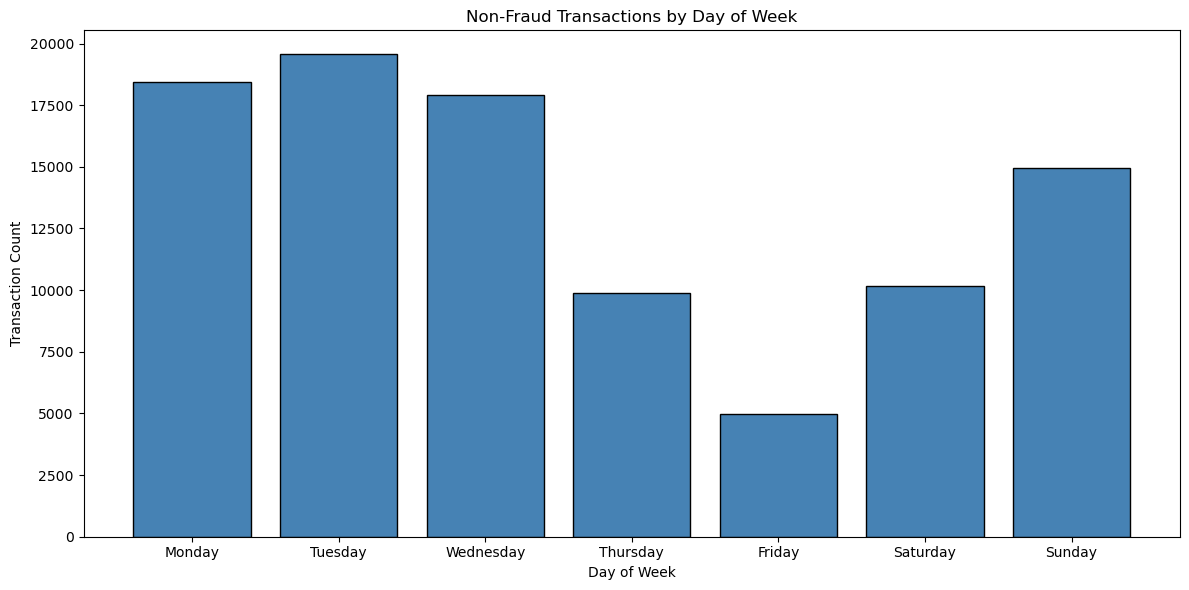

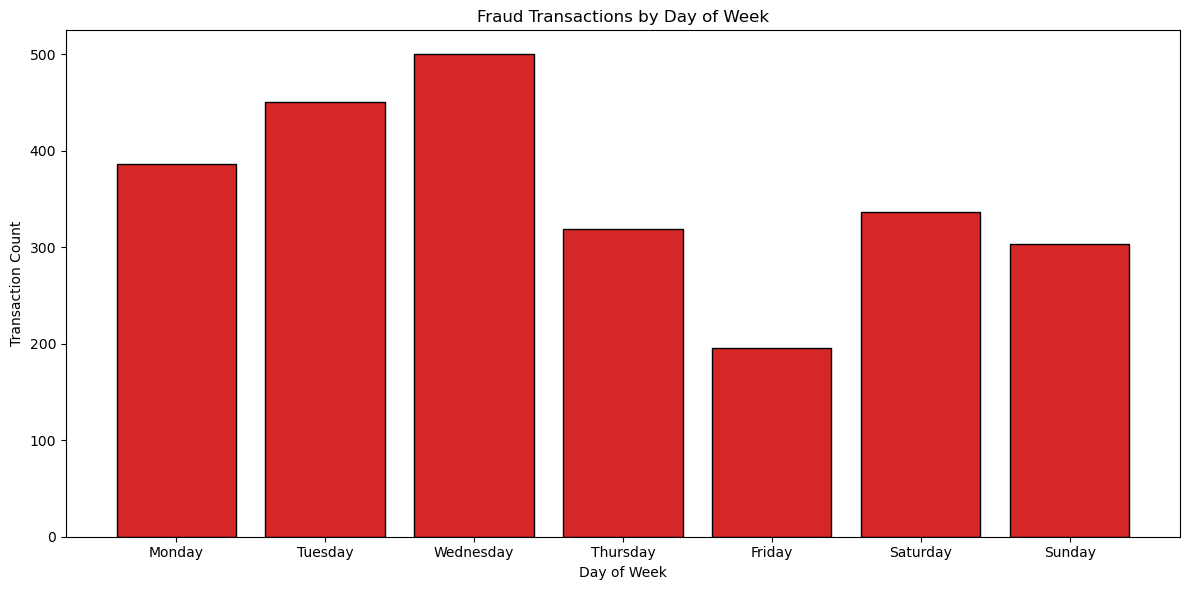

In [49]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Non-fraud transactions
non_fraud = df[df['Fraud'] == 0]['day_of_week'].value_counts().reindex(day_order)
plt.figure(figsize=(12, 6))
plt.bar(non_fraud.index, non_fraud.values, edgecolor='black', color='steelblue')
plt.xlabel('Day of Week')
plt.ylabel('Transaction Count')
plt.title('Non-Fraud Transactions by Day of Week')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Fraud transactions
fraud = df[df['Fraud'] == 1]['day_of_week'].value_counts().reindex(day_order)
plt.figure(figsize=(12, 6))
plt.bar(fraud.index, fraud.values, edgecolor='black', color='tab:red')
plt.xlabel('Day of Week')
plt.ylabel('Transaction Count')
plt.title('Fraud Transactions by Day of Week')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

There tends to be less transactions on Thursday, Friday, and Saturday.

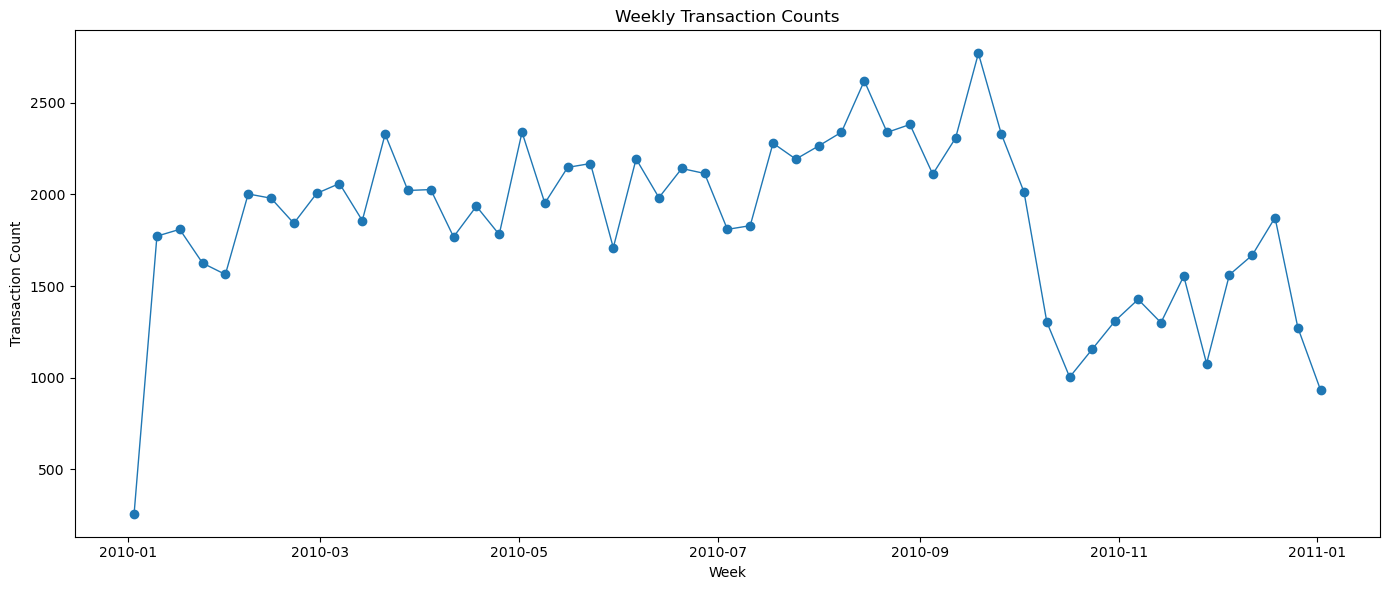

In [50]:
weekly_counts = df.set_index('Date').resample('W').size()

plt.figure(figsize=(14, 6))
plt.plot(weekly_counts.index, weekly_counts.values, marker='o', linewidth=1)
plt.xlabel('Week')
plt.ylabel('Transaction Count')
plt.title('Weekly Transaction Counts')
plt.tight_layout()
plt.show()

A significant decline in transactions occurs around October, which aligns with the renewal of the fiscal year. This suggests that business spending increases before the renewal and becomes more conservative immediately after.

#### Fraud

This is a highly imbalanced dataset, undersampling or oversampling would be best when building models later on.

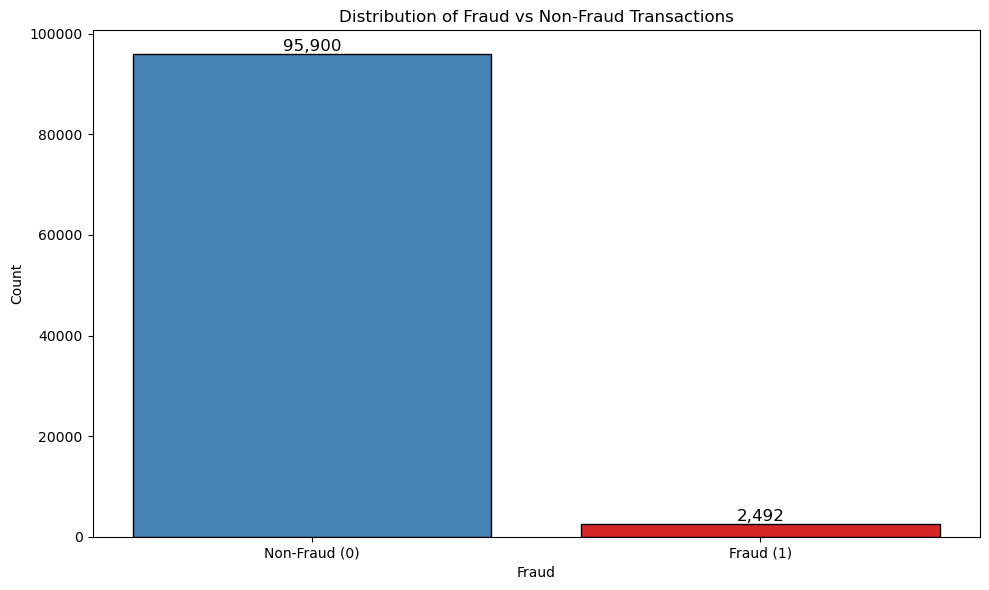

In [51]:
fraud_counts = df['Fraud'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(fraud_counts.index, fraud_counts.values, edgecolor='black', color=['steelblue', 'tab:red'])
plt.xlabel('Fraud')
plt.ylabel('Count')
plt.title('Distribution of Fraud vs Non-Fraud Transactions')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

#### Transaction Type

Best guess for the codes:
- P: Purchase
- A: Authorization without a purchase (deposit for hotels, renting a car, etc.)
- D: Declined
- Y: anomaly?

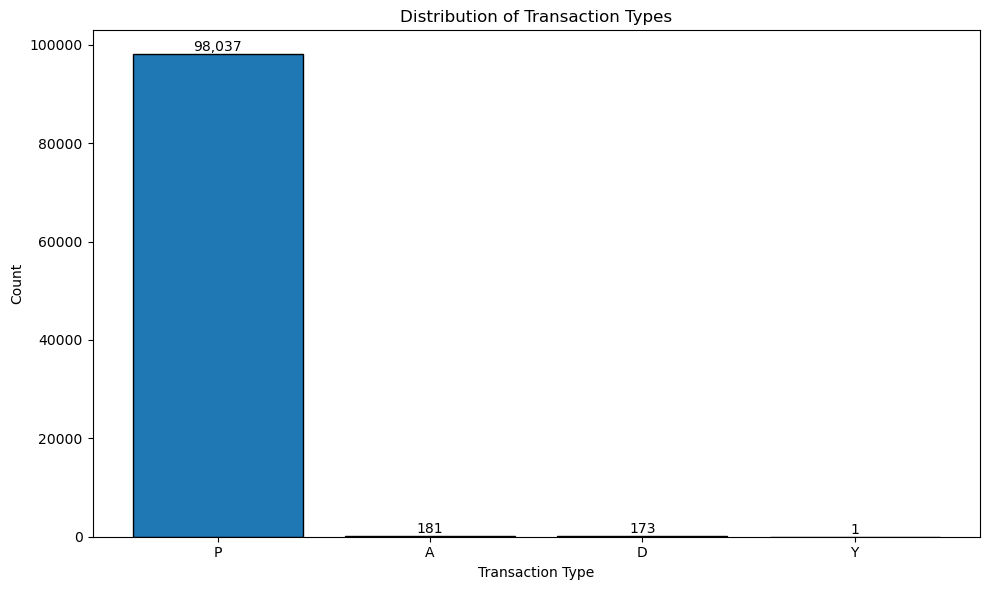

In [52]:
type_counts = df['Transtype'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(type_counts.index, type_counts.values, edgecolor='black')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [53]:
df.groupby(['Transtype', 'Fraud']).size().unstack(fill_value=0)

Fraud,0,1
Transtype,,
A,181,0
D,173,0
P,95545,2492
Y,1,0


As there is no fraudulent transactions in any of the categories other than P, we can safely remove the other ones, especially considering their sizes.

#### All Other Categorical Fields

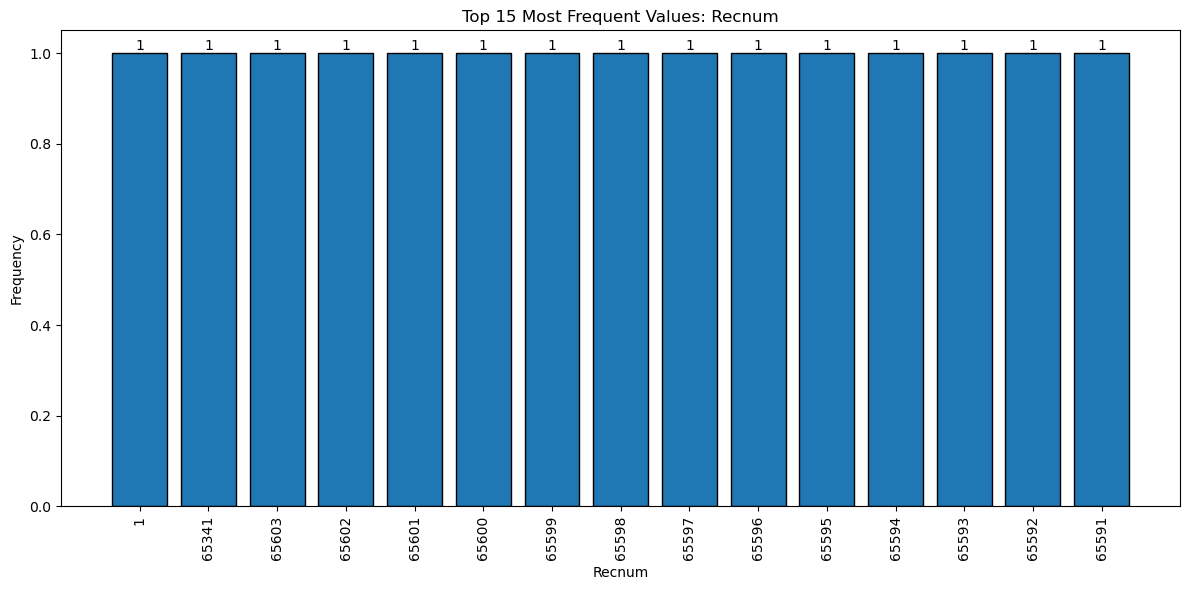

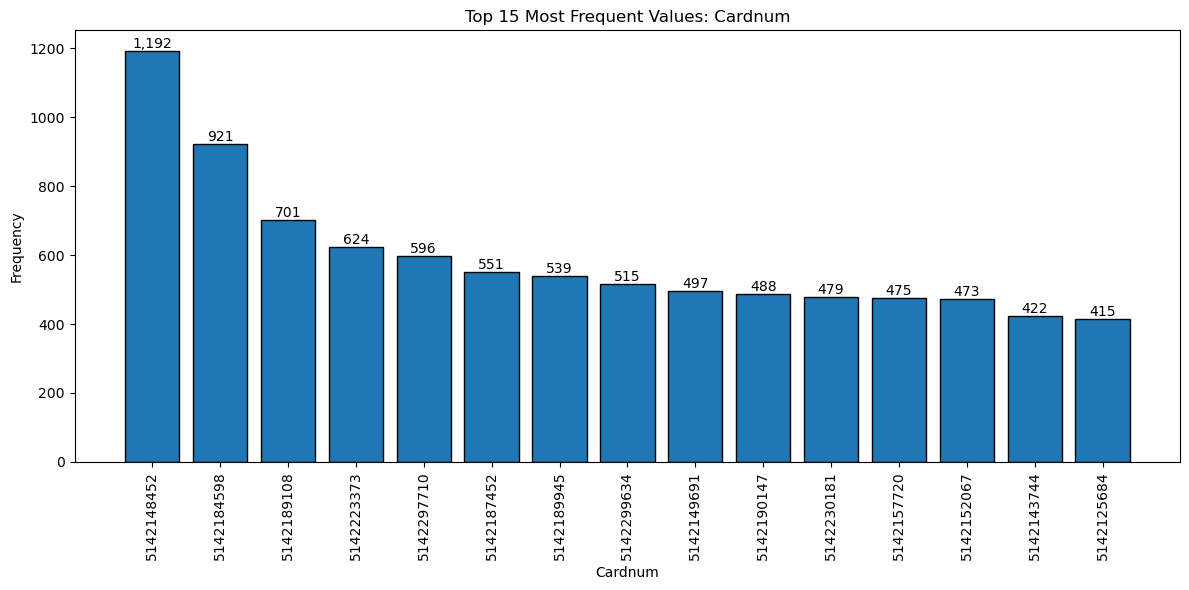

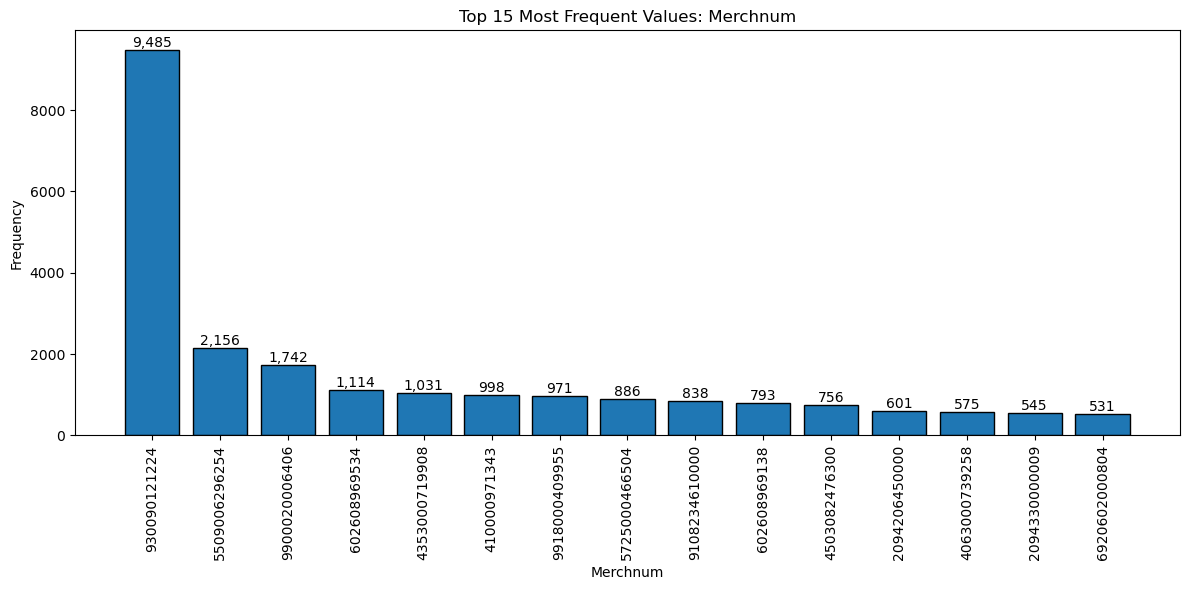

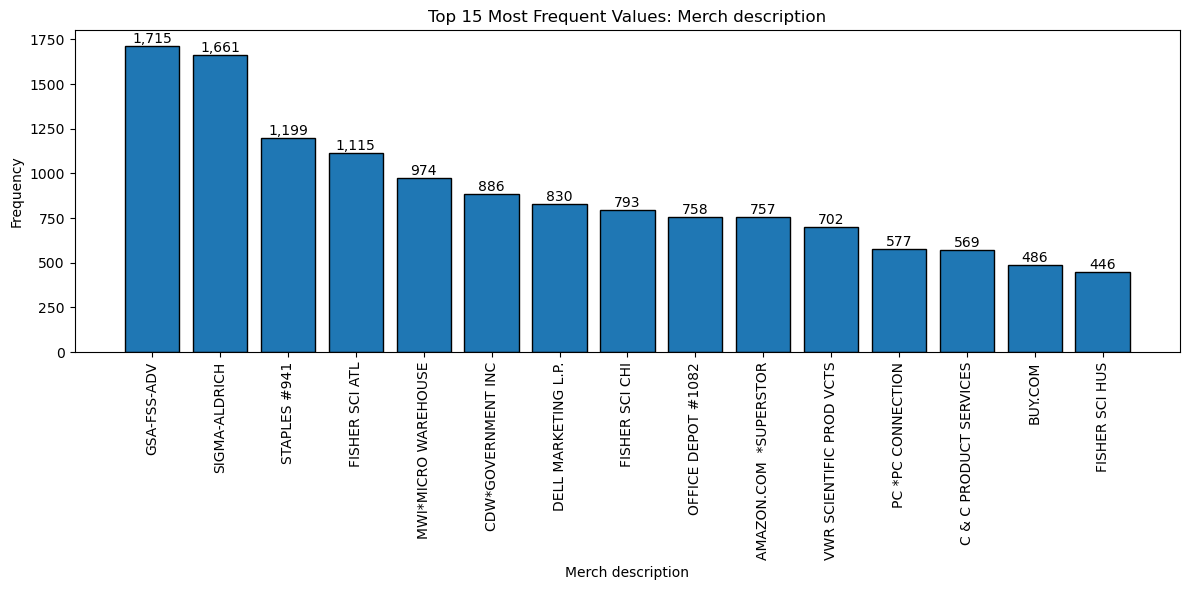

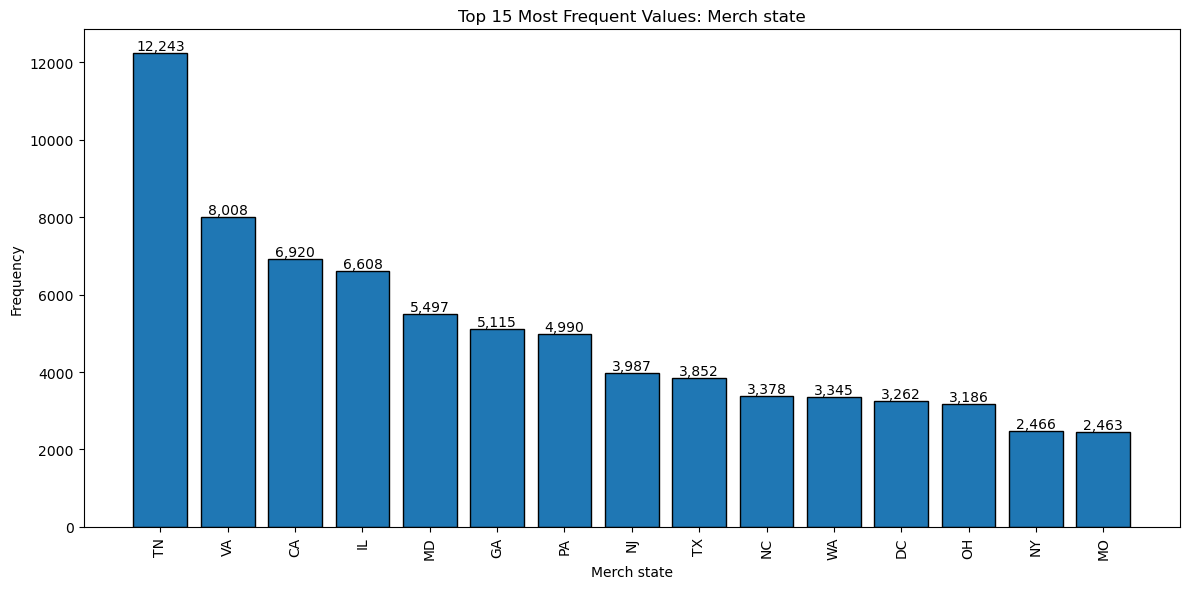

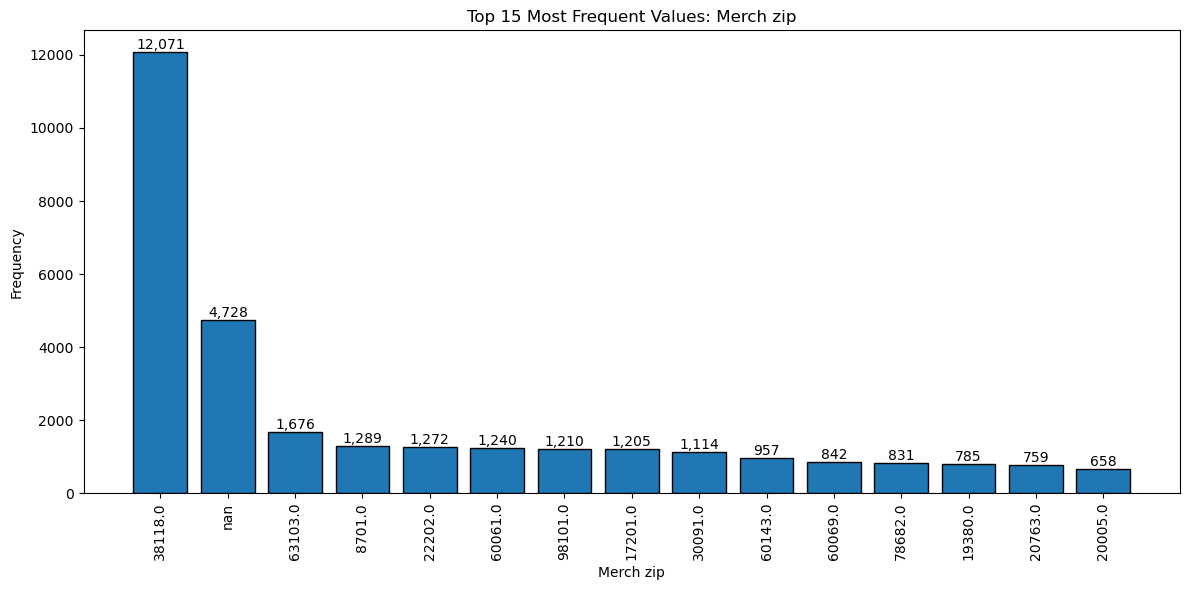

In [54]:
exclude_cols = ['Date', 'Transtype', 'Amount', 'Fraud', 'day_of_week']
categorical_cols = [col for col in df.columns if col not in exclude_cols]

for col in categorical_cols:
    counts = df[col].value_counts().head(15)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(counts)), counts.values, edgecolor='black')
    plt.xticks(range(len(counts)), counts.index, rotation=90)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Top 15 Most Frequent Values: {col}')
    
    for i, v in enumerate(counts.values):
        plt.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

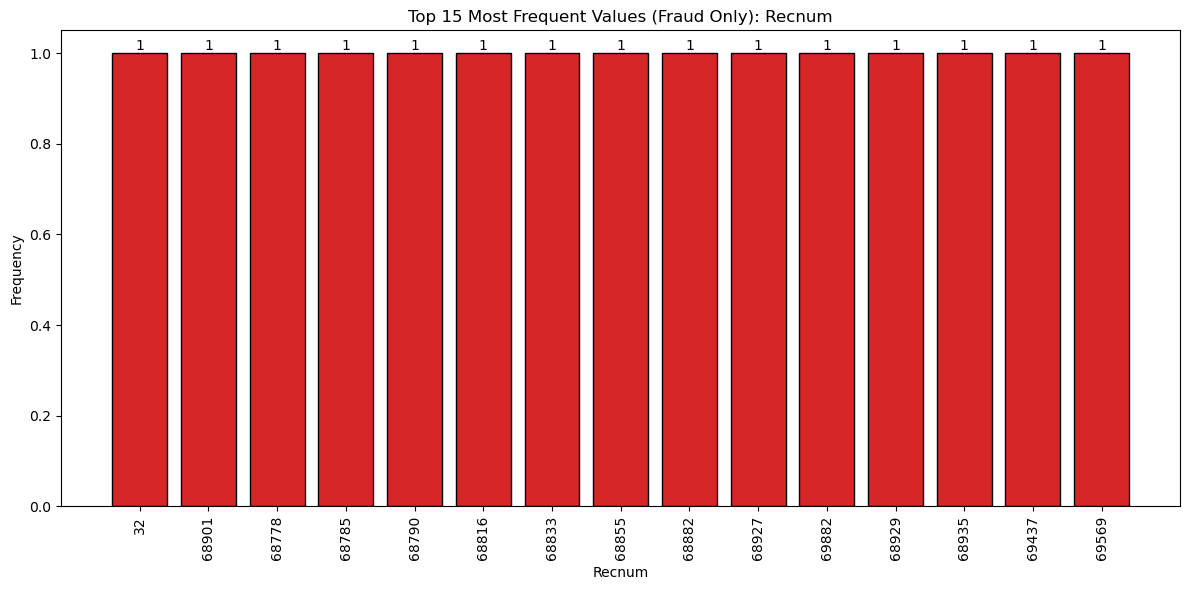

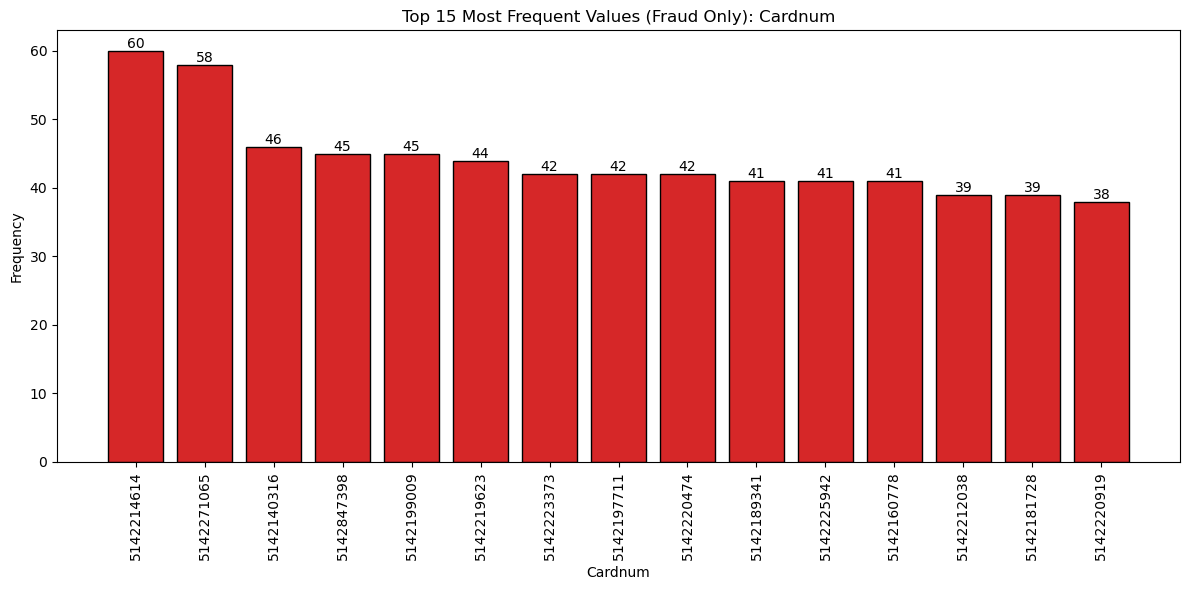

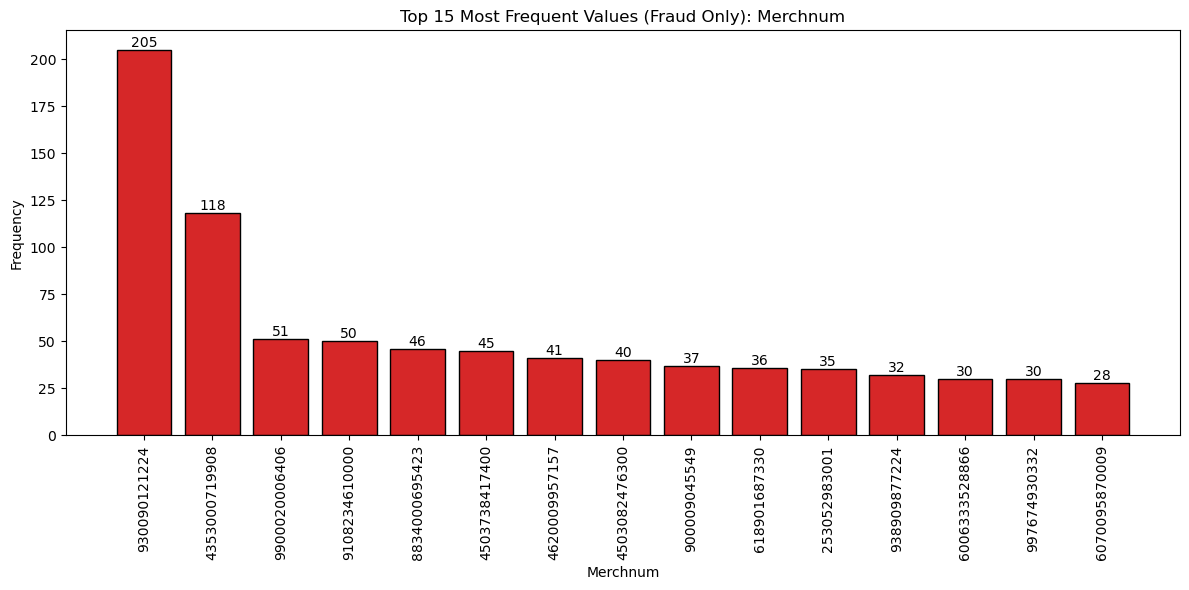

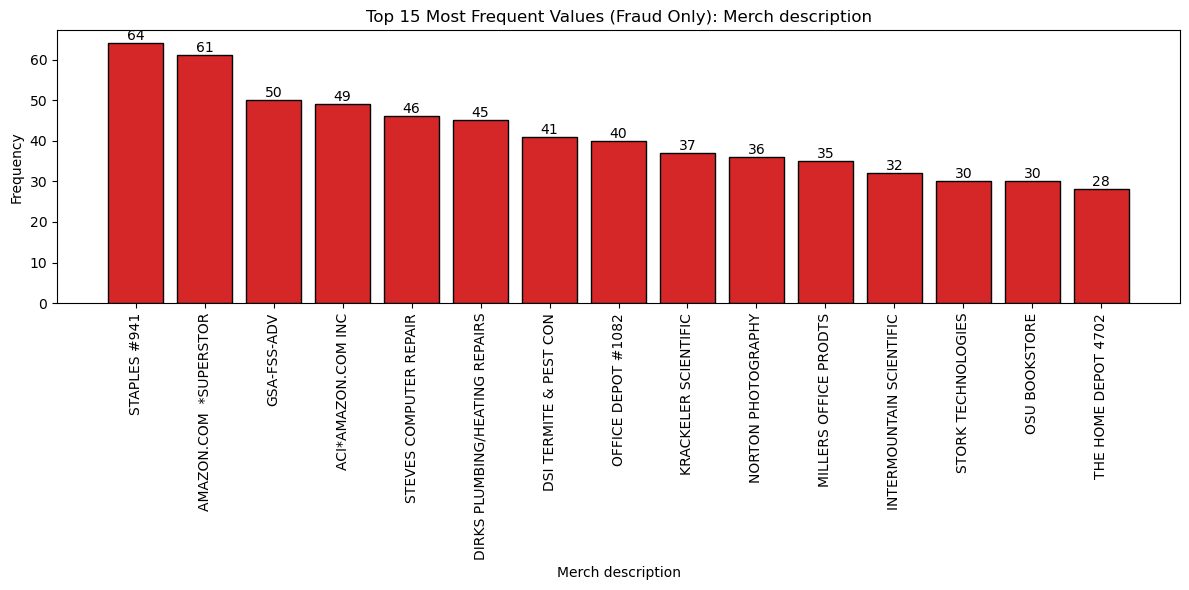

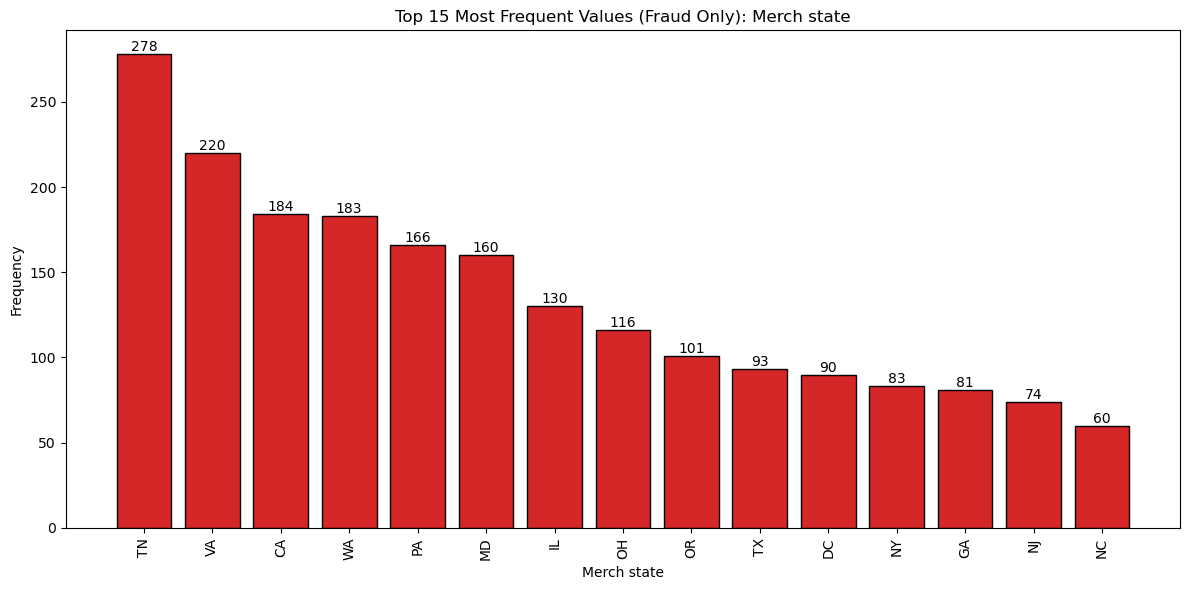

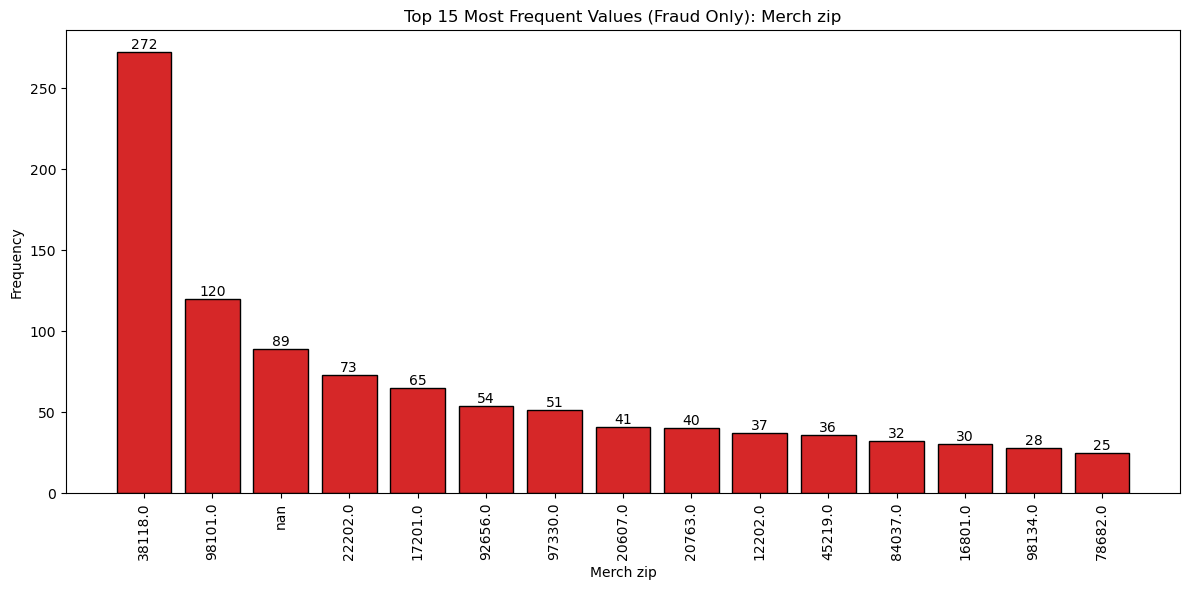

In [55]:
exclude_cols = ['Date', 'Transtype', 'Amount', 'Fraud', 'day_of_week']
categorical_cols = [col for col in df.columns if col not in exclude_cols]

fraud_df = df[df['Fraud'] == 1]

for col in categorical_cols:
    counts = fraud_df[col].value_counts().head(15)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(counts)), counts.values, edgecolor='black', color='tab:red')
    plt.xticks(range(len(counts)), counts.index, rotation=90)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Top 15 Most Frequent Values (Fraud Only): {col}')
    
    for i, v in enumerate(counts.values):
        plt.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

#### Exploration of Univariate Relationship with Y (Fraud)

In [56]:
pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[col].nunique() for col in df.columns]
}).sort_values('Unique Values', ascending=False)

,Column,Unique Values
0,Recnum,98392
8,Amount,35564
4,Merch description,13125
3,Merchnum,13091
6,Merch zip,4568
1,Cardnum,1645
2,Date,365
5,Merch state,227
10,day_of_week,7
7,Transtype,4


The Fraud Rate Relative to Baseline metric helps identify which values within a feature are associated with higher or lower fraud risk:

- **Baseline (black line at 1)**: Represents the overall fraud rate across all transactions
- **Values > 1**: This category has a **higher fraud rate** than average (e.g., 2.0 means 2x the baseline fraud rate)
- **Values < 1**: This category has a **lower fraud rate** than average (e.g., 0.5 means half the baseline fraud rate)
- **Values = 1**: This category has the **same fraud rate** as the overall average

Overall fraud rate: 0.0253


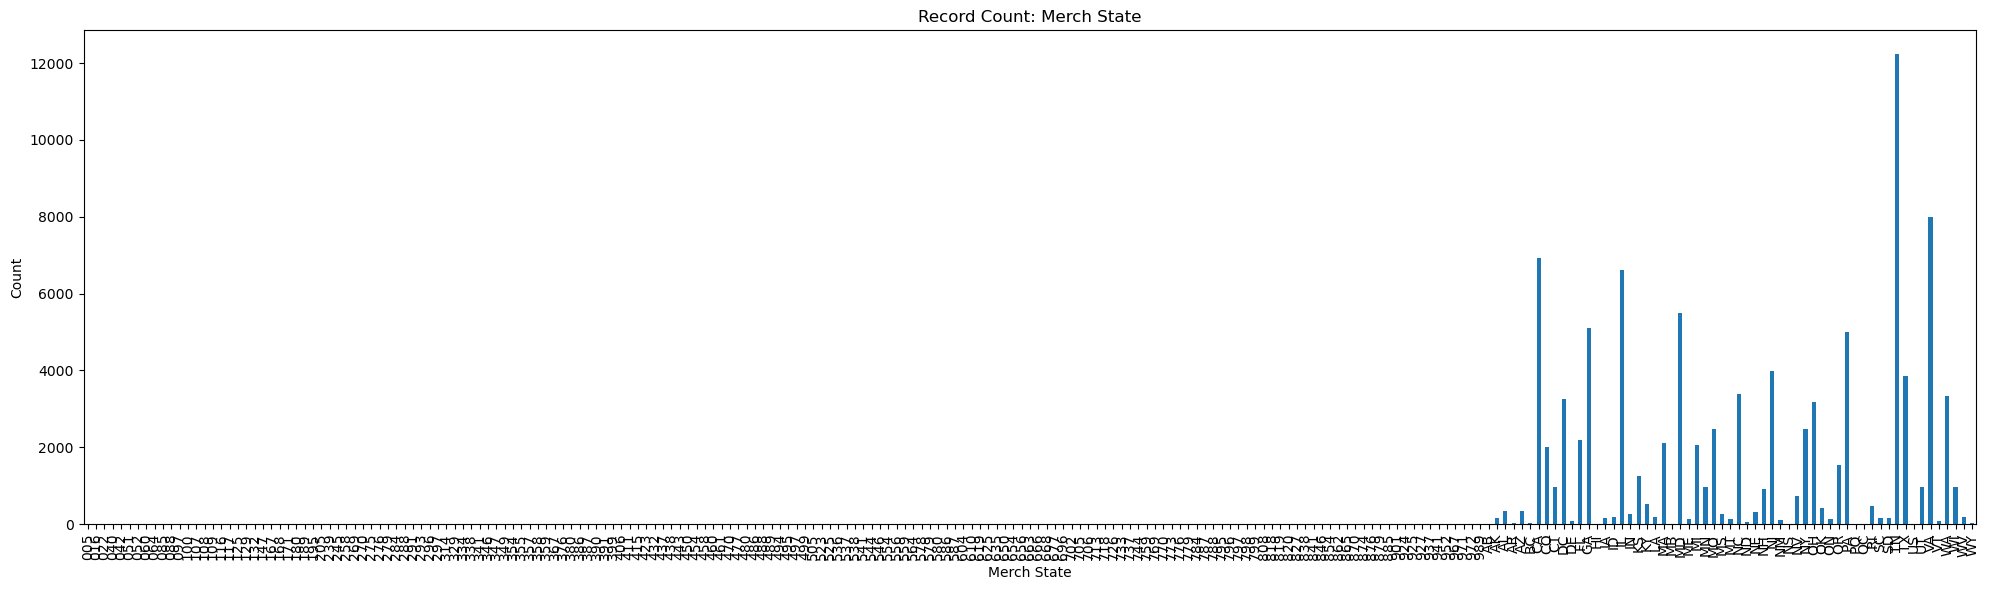

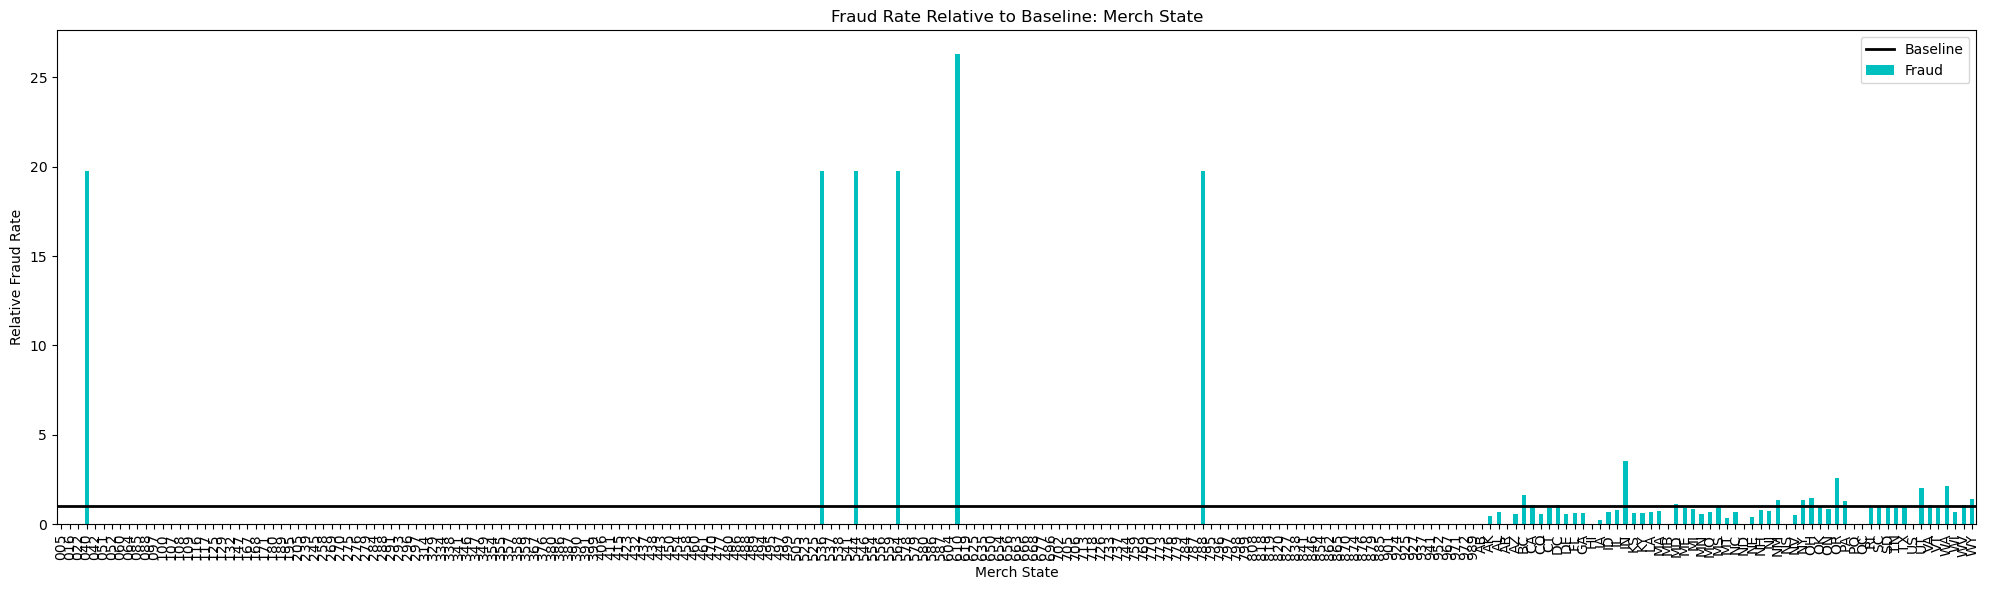

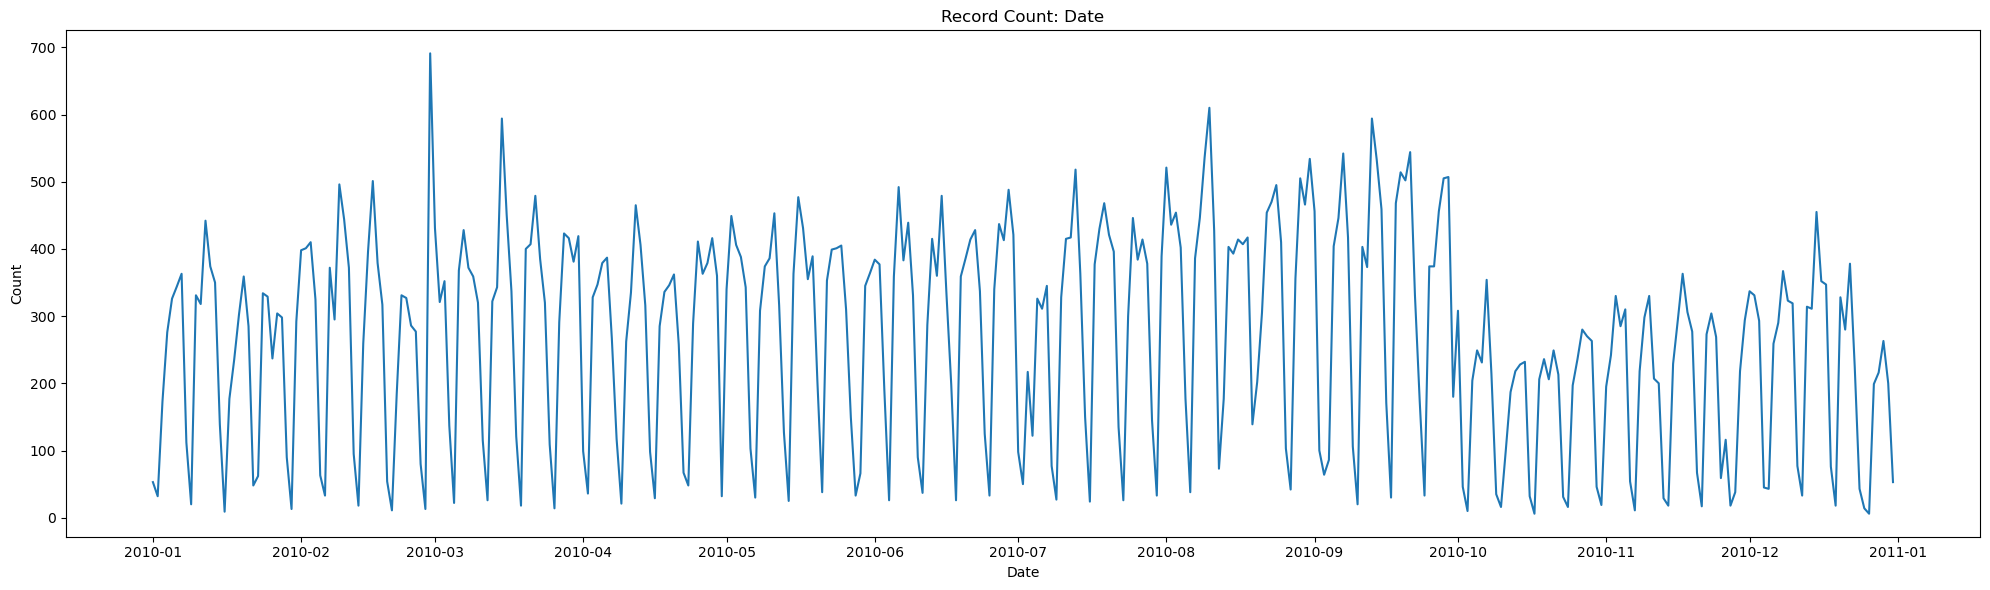

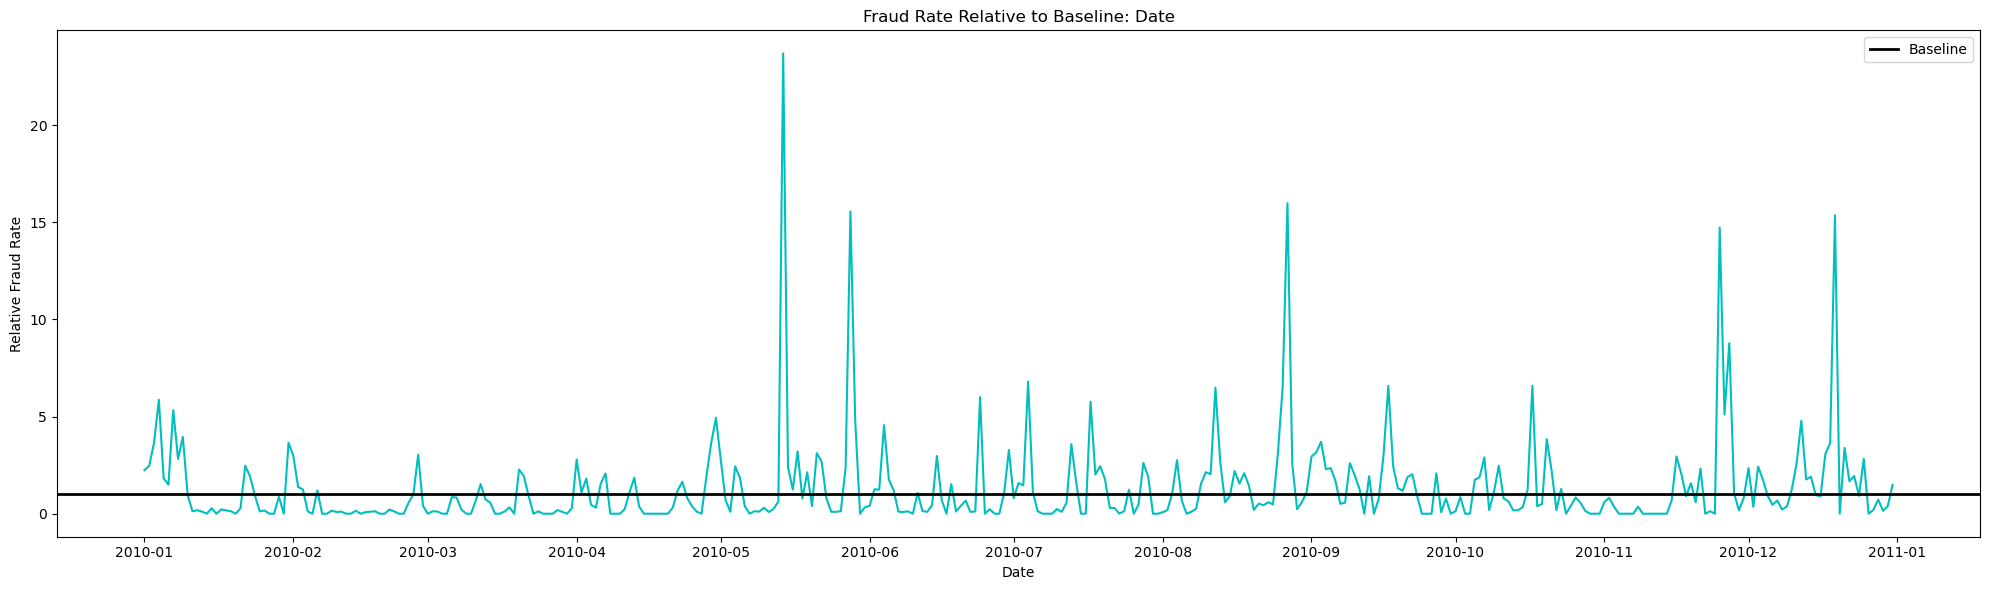

In [57]:
import matplotlib.dates as mdates

dep_var = 'Fraud'
rate = df[dep_var].mean()
print(f'Overall fraud rate: {rate:.4f}')

# Merch state analysis
state_counts = df['Merch state'].value_counts().sort_index()
plt.figure(figsize=(20, 6))
state_counts.plot(kind='bar')
plt.xlabel('Merch State')
plt.ylabel('Count')
plt.title('Record Count: Merch State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

fraud_rate_state = df.groupby('Merch state')[dep_var].mean() / rate
plt.figure(figsize=(20, 6))
fraud_rate_state.plot(kind='bar', color='c')
plt.axhline(1, color='black', linewidth=2, label='Baseline')
plt.xlabel('Merch State')
plt.ylabel('Relative Fraud Rate')
plt.title('Fraud Rate Relative to Baseline: Merch State')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Date analysis
date_counts = df.groupby('Date').size()
plt.figure(figsize=(20, 6))
plt.plot(date_counts.index, date_counts.values)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Record Count: Date')
plt.tight_layout()
plt.show()

fraud_rate_date = df.groupby('Date')[dep_var].mean() / rate
plt.figure(figsize=(20, 6))
plt.plot(fraud_rate_date.index, fraud_rate_date.values, color='c')
plt.axhline(1, color='black', linewidth=2, label='Baseline')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date')
plt.ylabel('Relative Fraud Rate')
plt.title('Fraud Rate Relative to Baseline: Date')
plt.legend()
plt.tight_layout()
plt.show()